# Imports

In [1]:
import sys
import os
from pathlib import Path

In [2]:
sys.path.append(os.path.join(os.getcwd(),"..",".."))
sys.path.append(os.path.join(os.getcwd(),"..","..",".."))

In [3]:
import numpy as np
import pandas as pd

In [4]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
from backtester import BackTester

In [8]:
data_store=Path(os.getcwd()).parent.parent.parent/"Prepared_Data_Store"

# Loading Benchmark Data

In [9]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [10]:
benchmark_data=benchmark_data.sp500_returns.sort_index().tz_localize("UTC")

# BackTesting

## Trading Strategy-I

### Here we will long the stocks with higher factor values and short the stocks with lower factor values predicted by Ridge Model-17 with reg_aplha=10000

In [11]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [12]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.01,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge17_factor",
    trading_strategy=trading_strategy
)

In [13]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

In [14]:
LIVE_DATE="2016-02-24"

#### Extracting Information from Zipline Results

In [15]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

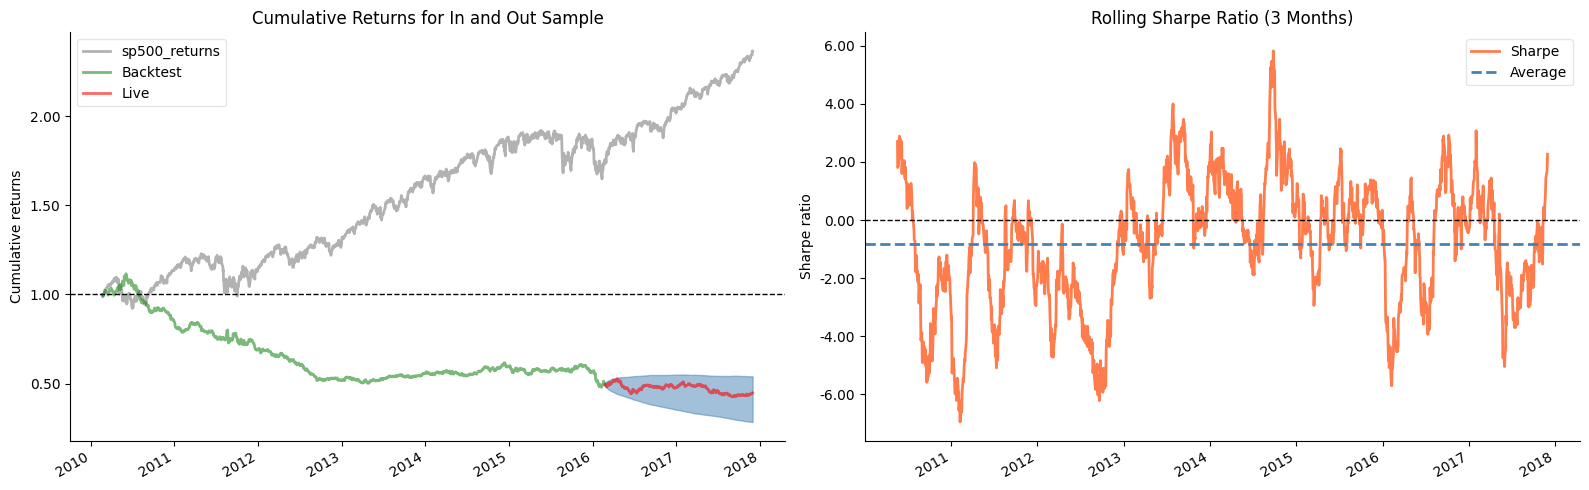

In [16]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    volatility_match=False,
    legend_loc="best",
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,61.92,2010-06-04,2017-08-31,NaT,NaN
1,3.99,2010-03-31,2010-04-14,2010-04-30,23
2,2.57,2010-03-04,2010-03-18,2010-03-24,15
3,2.42,2010-05-06,2010-05-10,2010-05-19,10
4,2.30,2010-05-20,2010-05-25,2010-05-27,6


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.03%,-3.33%,4.47%
Fukushima,0.02%,-1.05%,0.72%
EZB IR Event,-0.13%,-2.36%,1.32%
Flash Crash,-0.22%,-1.53%,0.81%
Apr14,-0.08%,-2.47%,1.08%
Oct14,-0.09%,-1.41%,1.19%
Fall2015,-0.07%,-2.10%,1.76%
Recovery,-0.09%,-3.33%,4.47%
New Normal,-0.01%,-3.06%,3.75%


Top 10 long positions of all time,max
sid,
MOS,34.14%
NEM,29.93%
OKE,29.33%
ERIE,26.70%
NRG,26.24%
HSY,25.10%
AZO,23.46%
FCX,21.71%
BMY,21.21%


Top 10 short positions of all time,max
sid,
OKE,-34.24%
ERIE,-31.47%
MOS,-29.78%
WTW,-26.86%
WSM,-26.80%
BMY,-26.39%
APA,-26.11%
CF,-25.76%
WYNN,-25.69%


Top 10 positions of all time,max
sid,
OKE,34.24%
MOS,34.14%
ERIE,31.47%
NEM,29.93%
WTW,26.86%
WSM,26.80%
BMY,26.39%
NRG,26.24%
APA,26.11%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-521324.35,$-875783.33,$354458.98
Gross profit,$13136808.63,$6325148.51,$6811660.11
Gross loss,$-13658132.98,$-7200931.84,$-6457201.13
Profit factor,$0.96,$0.88,$1.05
Avg. trade net profit,$-6.89,$-23.74,$9.13
Avg. winning trade,$353.58,$362.06,$346.05
Avg. losing trade,$-356.52,$-373.28,$-339.51
Ratio Avg. Win:Avg. Loss,$0.99,$0.97,$1.02
Largest winning trade,$18845.04,$14044.20,$18845.04
Largest losing trade,$-18916.94,$-10794.15,$-18916.94


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 12:36:09.756686434,1 days 14:18:59.846825353,1 days 10:58:28.115435135
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,149 days 00:00:00,149 days 00:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.05%
Median returns all round_trips,-0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.04%,-0.03%
Largest winning trade,3.39%,1.99%,3.39%
Largest losing trade,-2.55%,-2.30%,-2.55%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.02%,0.00%,-0.01%,0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,-0.00%,-0.00%,0.01%,0.02%,0.00%,-0.00%,-0.01%,0.01%,0.01%,0.00%,0.01%,0.00%,0.00%,0.00%,-0.00%,0.01%,0.01%,0.02%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.01%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.00%,0.00%,-0.00%,0.01%,-0.01%,0.01%,0.01%,0.00%,-0.00%,-0.01%,-0.01%,0.01%,0.00%,0.00%,0.02%,0.00%,0.00%,0.01%,-0.01%,-0.00%,0.01%,-0.01%,0.00%,0.01%,0.00%,-0.01%,0.00%,0.00%,-0.00%,0.01%,0.01%,0.01%,0.02%,-0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.01%,0.01%,0.01%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,-0.01%,0.01%,0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,0.00%,0.01%,-0.01%,0.00%,0.01%,0.00%,0.01%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.01%,-0.01%,-0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.01%,-0.03%,-0.02%,-0.01%,-0.01%,-0.00%,0.01%,-0.02%,-0.02%,0.00%,0.00%,-0.01%,-0.01%,0.01%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.00%,-0.00%,-0.02%,-0.00%,-0.00%,-0.01%,-0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.01%,-0.00%,0.00%,-0.01%,-0.01%,0.00%,0.01%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.00%,0.00%,-0.01%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.01%,-0.01%,0.00%,0.01%,-0.02%,-0.01%,-0.00%,-0.01%,0.01%,0.01%,-0.03%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.02%,-0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,-0.01%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.01%,-0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.01%,-0.00%,0.00%,-0.00%,-0.01%,-0.00%,-0.01%,-0.01%,-0.01%,0.01%,-0.01%,-0.01%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,-0.03%,-0.01%,0.01%,-0.01%,0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.02%,-0.00%,0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.01%,-0.02%,-0.00%,0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.01%,0.00%,0.00%,-0.01%,-0.01%,0.02%,-0.01%,-0.01%,-0.00%,-0.01%,0.00%,0.01%,0.01%,0.00%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,-0.00%,-0.01%,0.00%,0.01%,-0.03%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.01%,-0.01%,0.01%,-0.00%,-0.02%,-0.00%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.

Profitability (PnL / PnL total) per name,
symbol,
VRTX,9.43%
MU,9.18%
AMD,7.21%
RF,6.61%
SMCI,6.34%
IDXX,6.16%
DAL,5.94%
TMUS,5.05%
MOS,4.98%


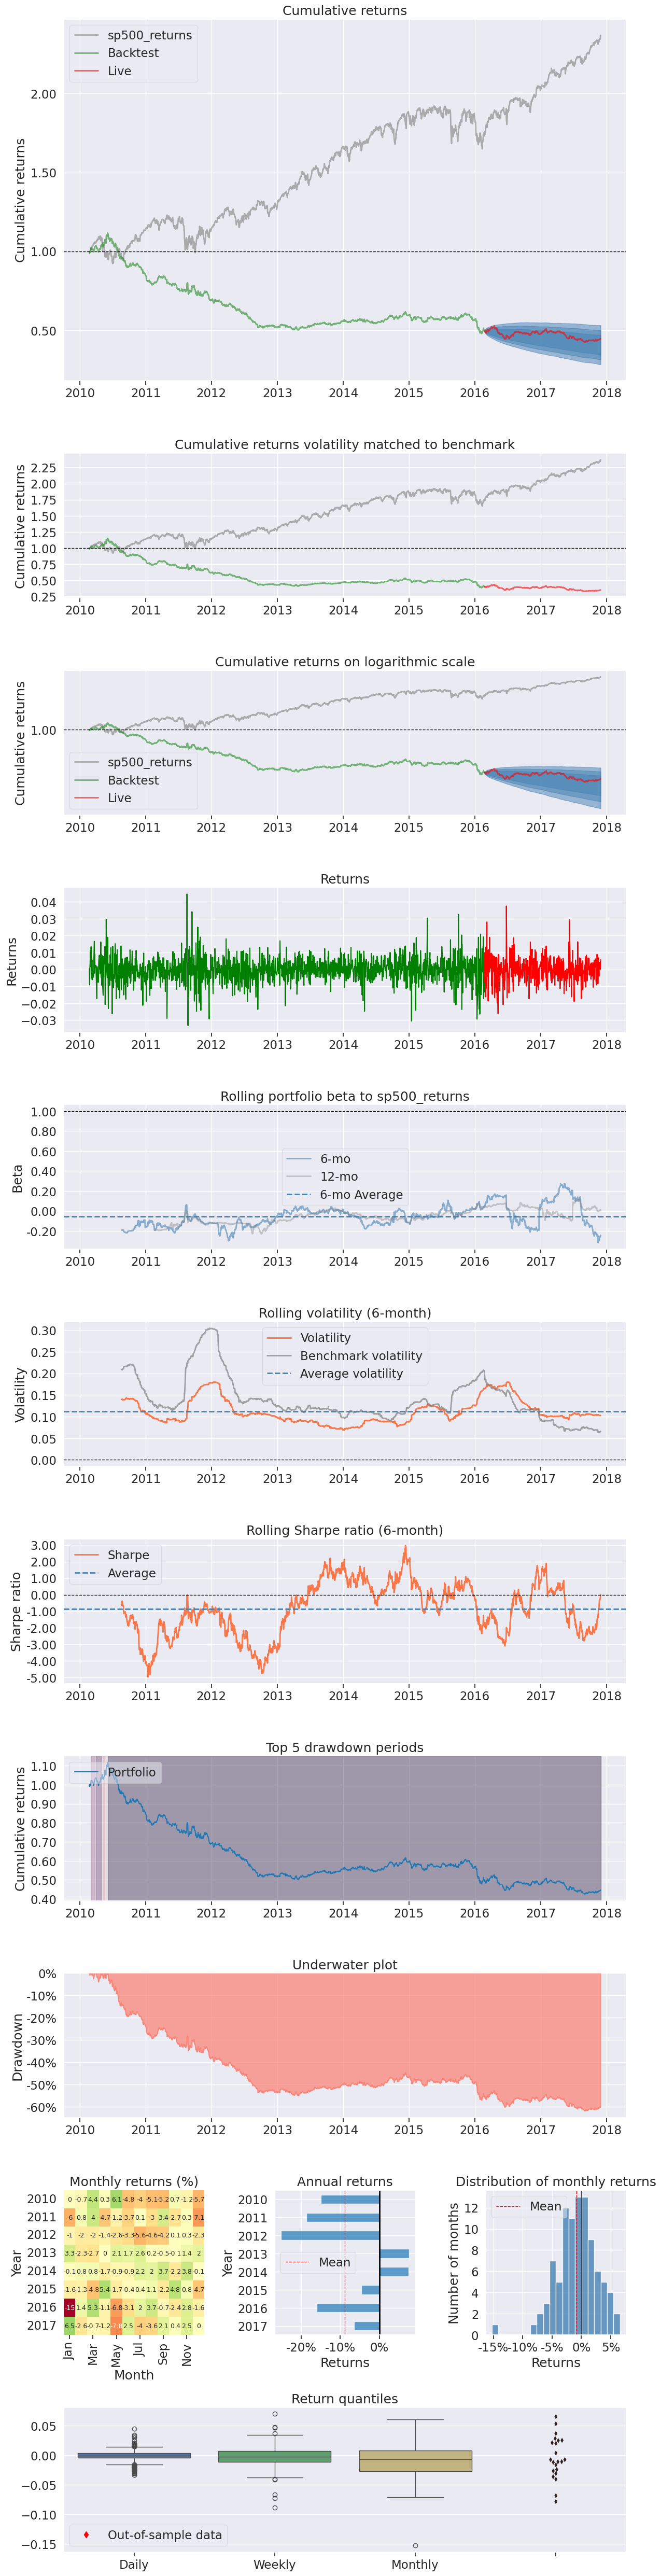

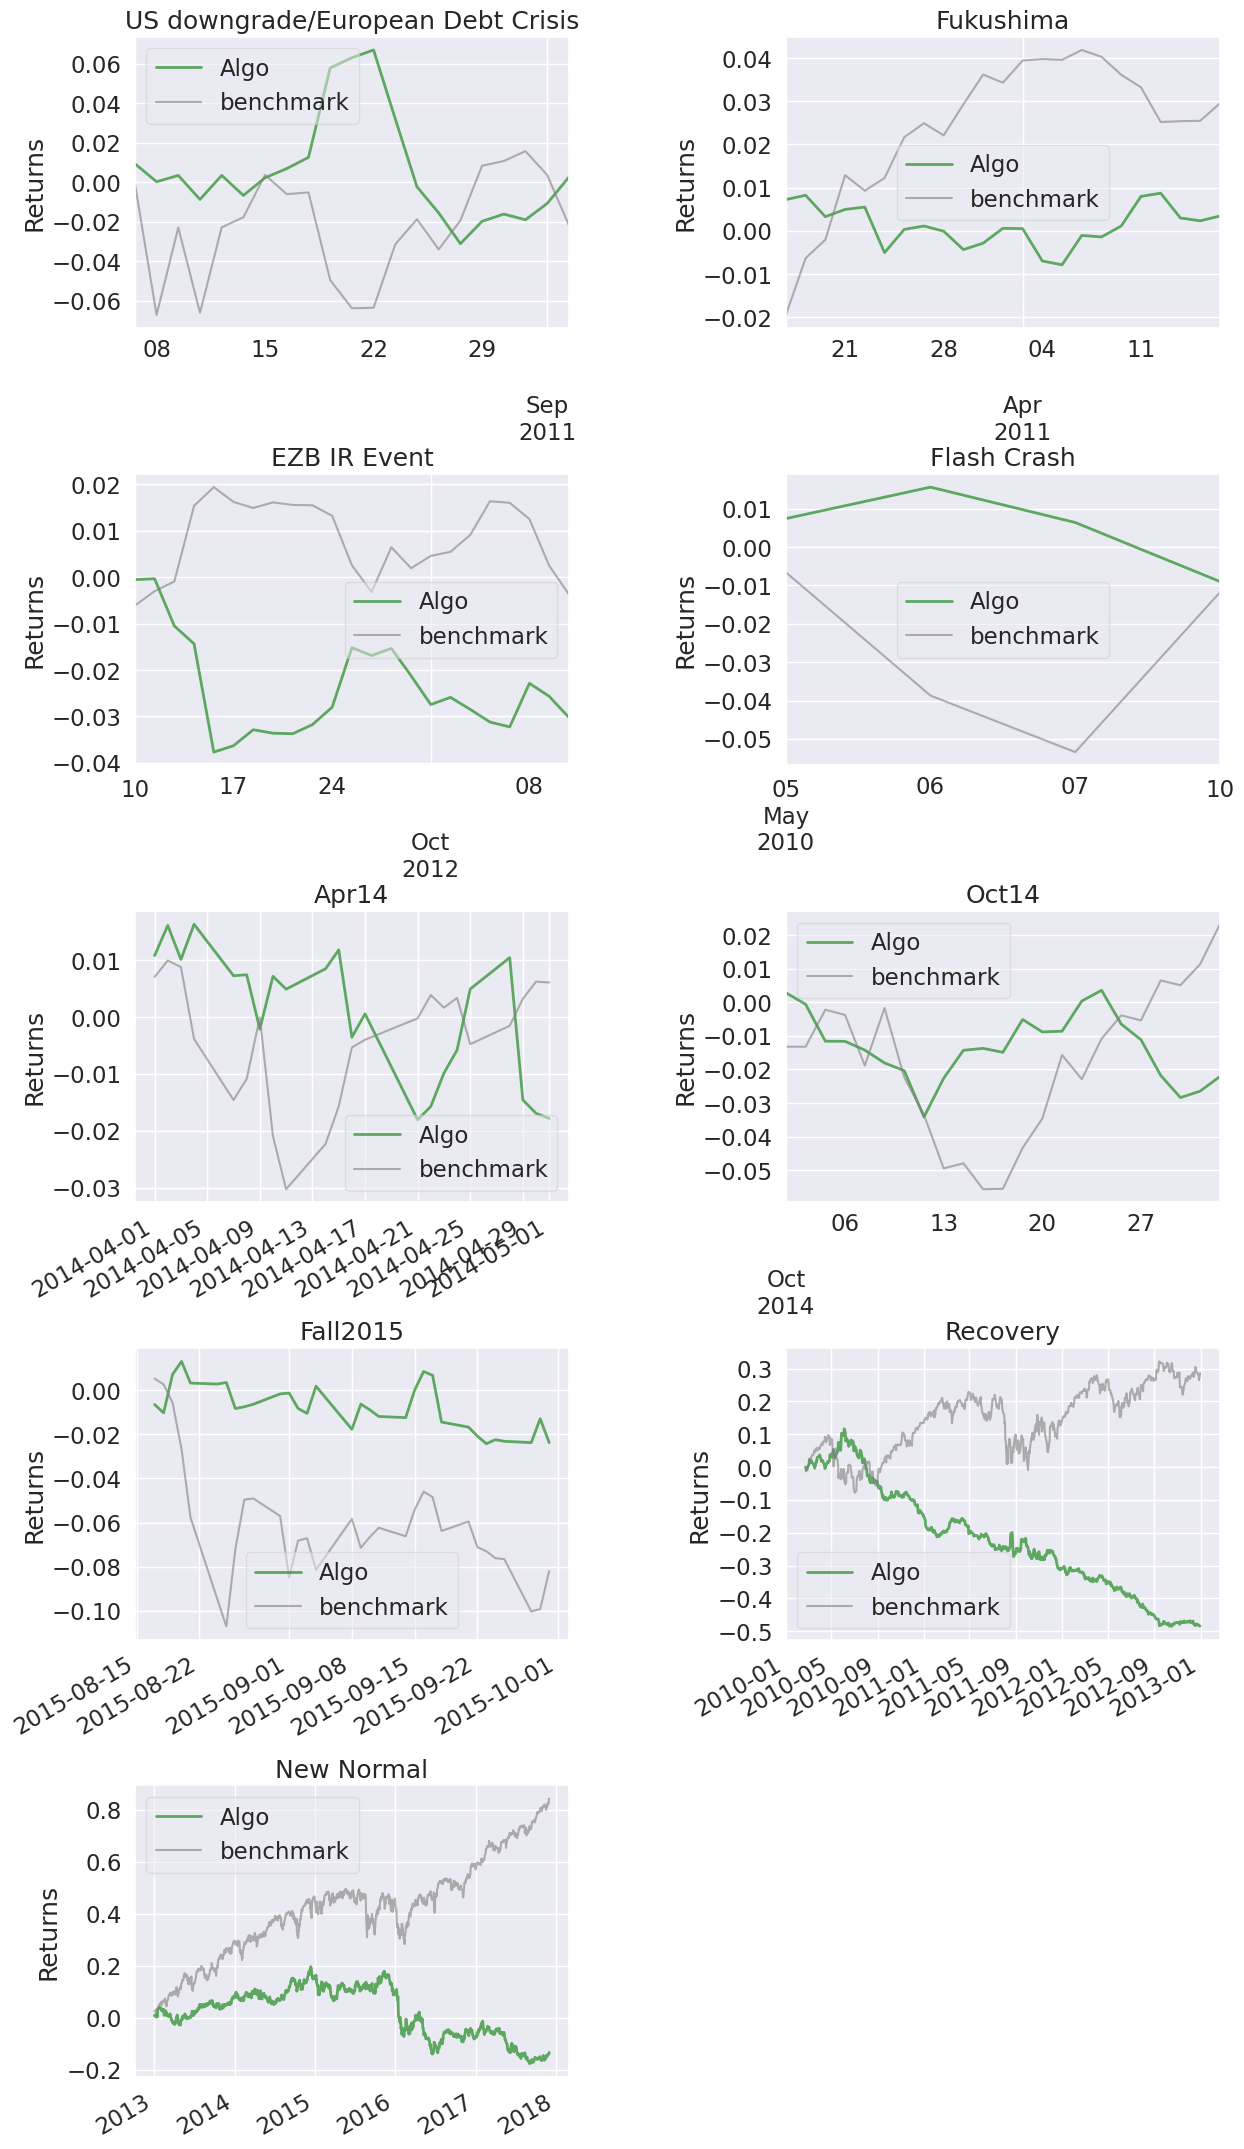

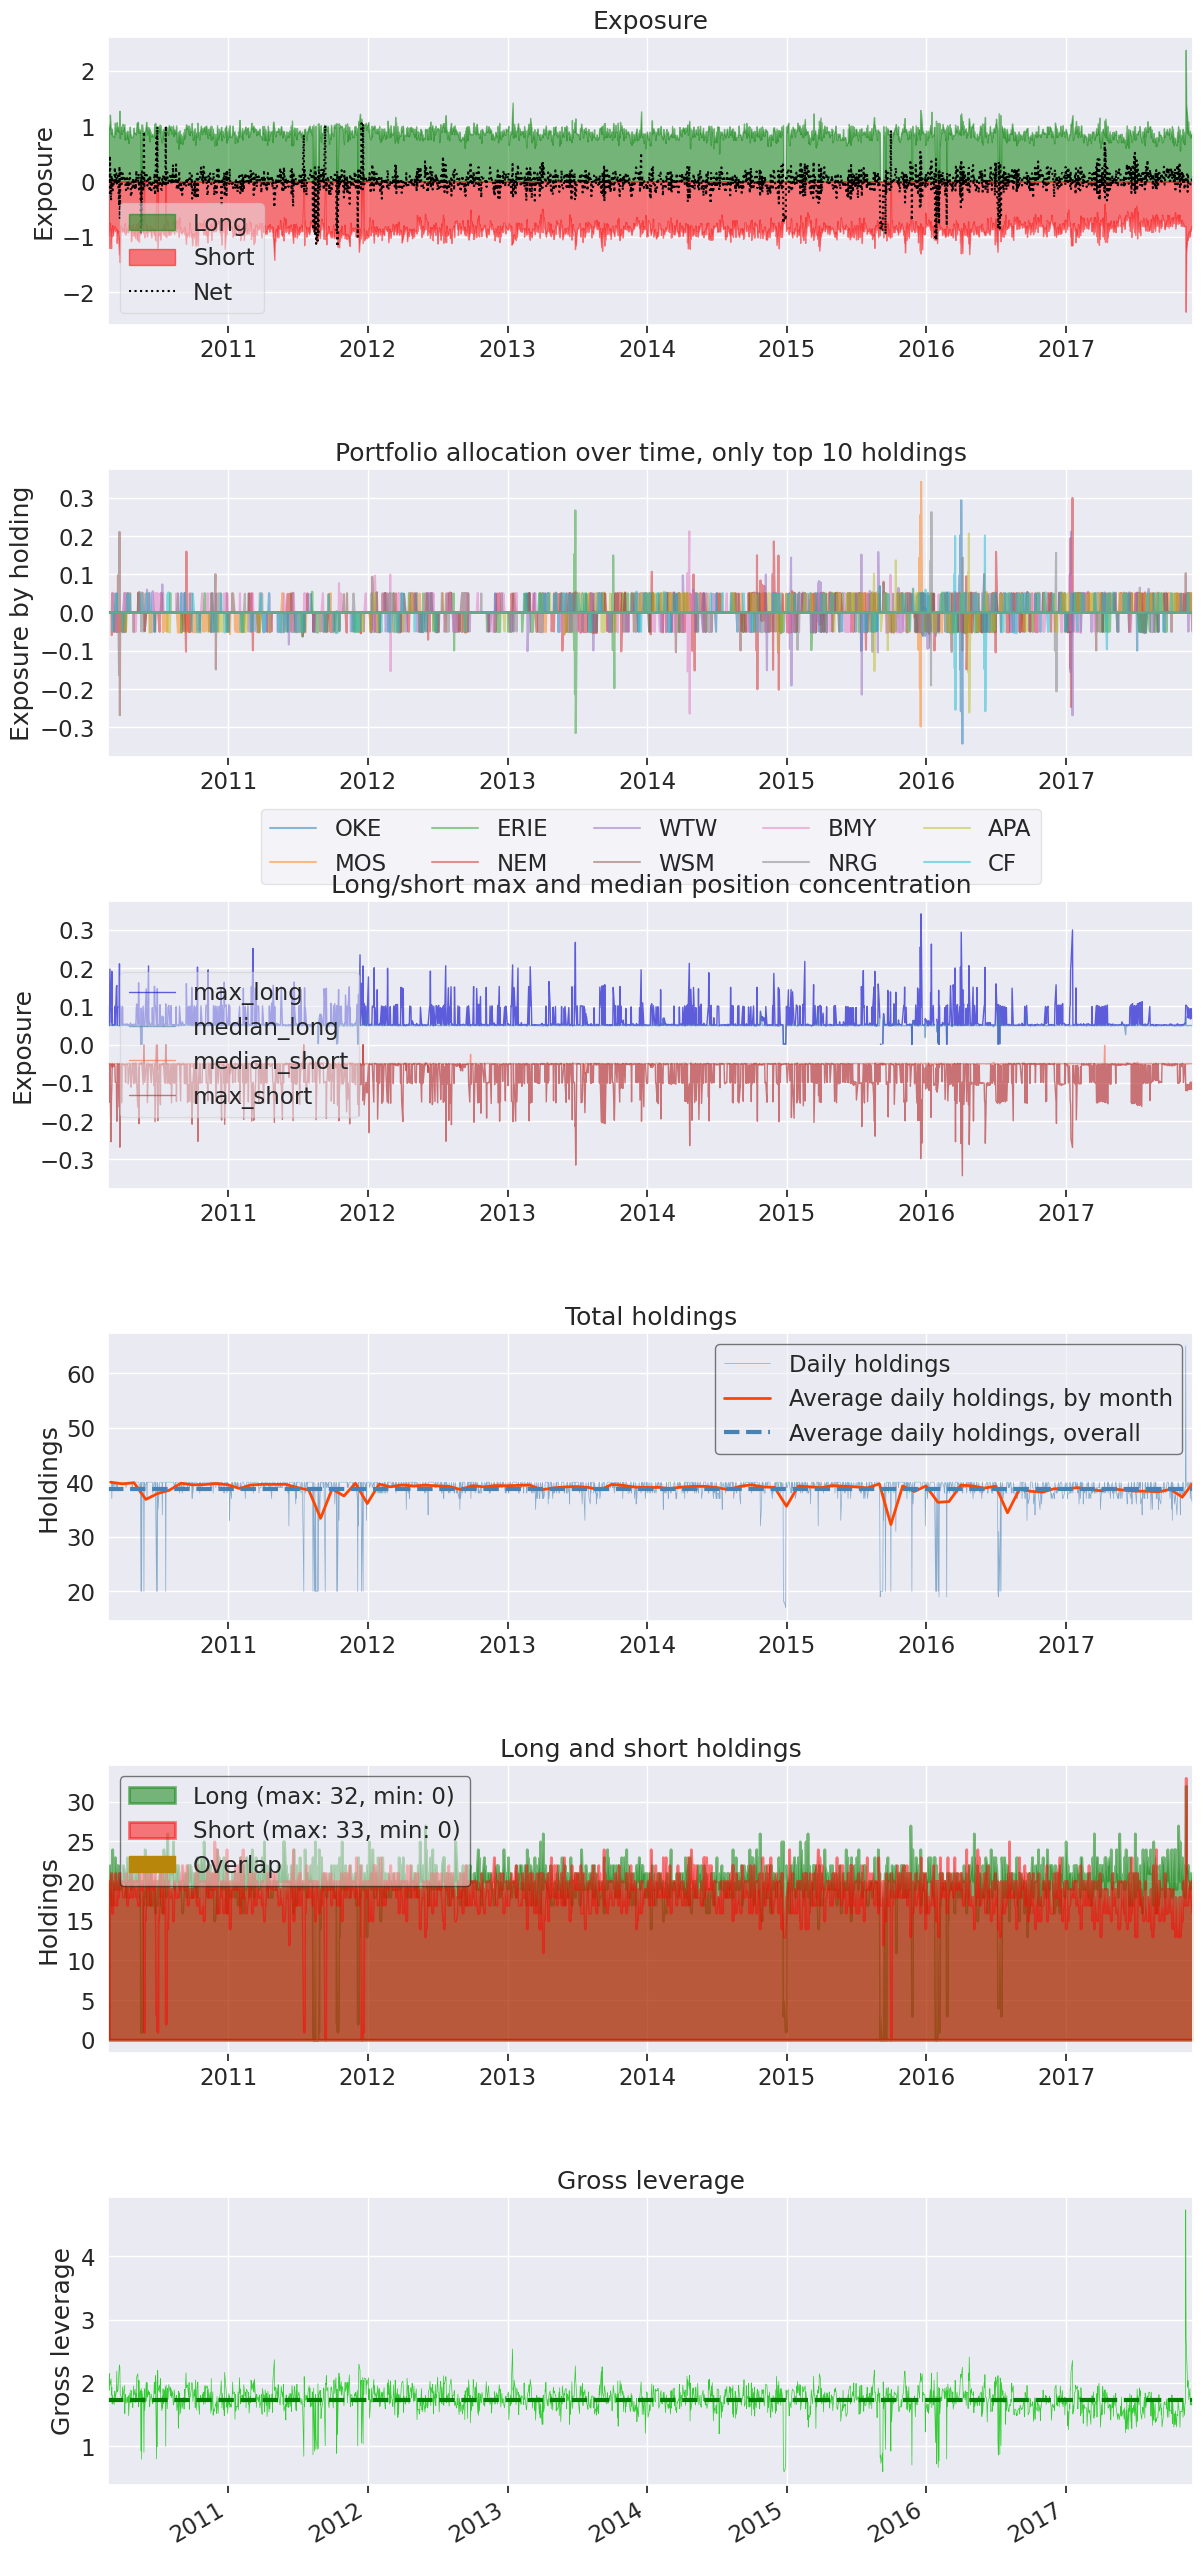

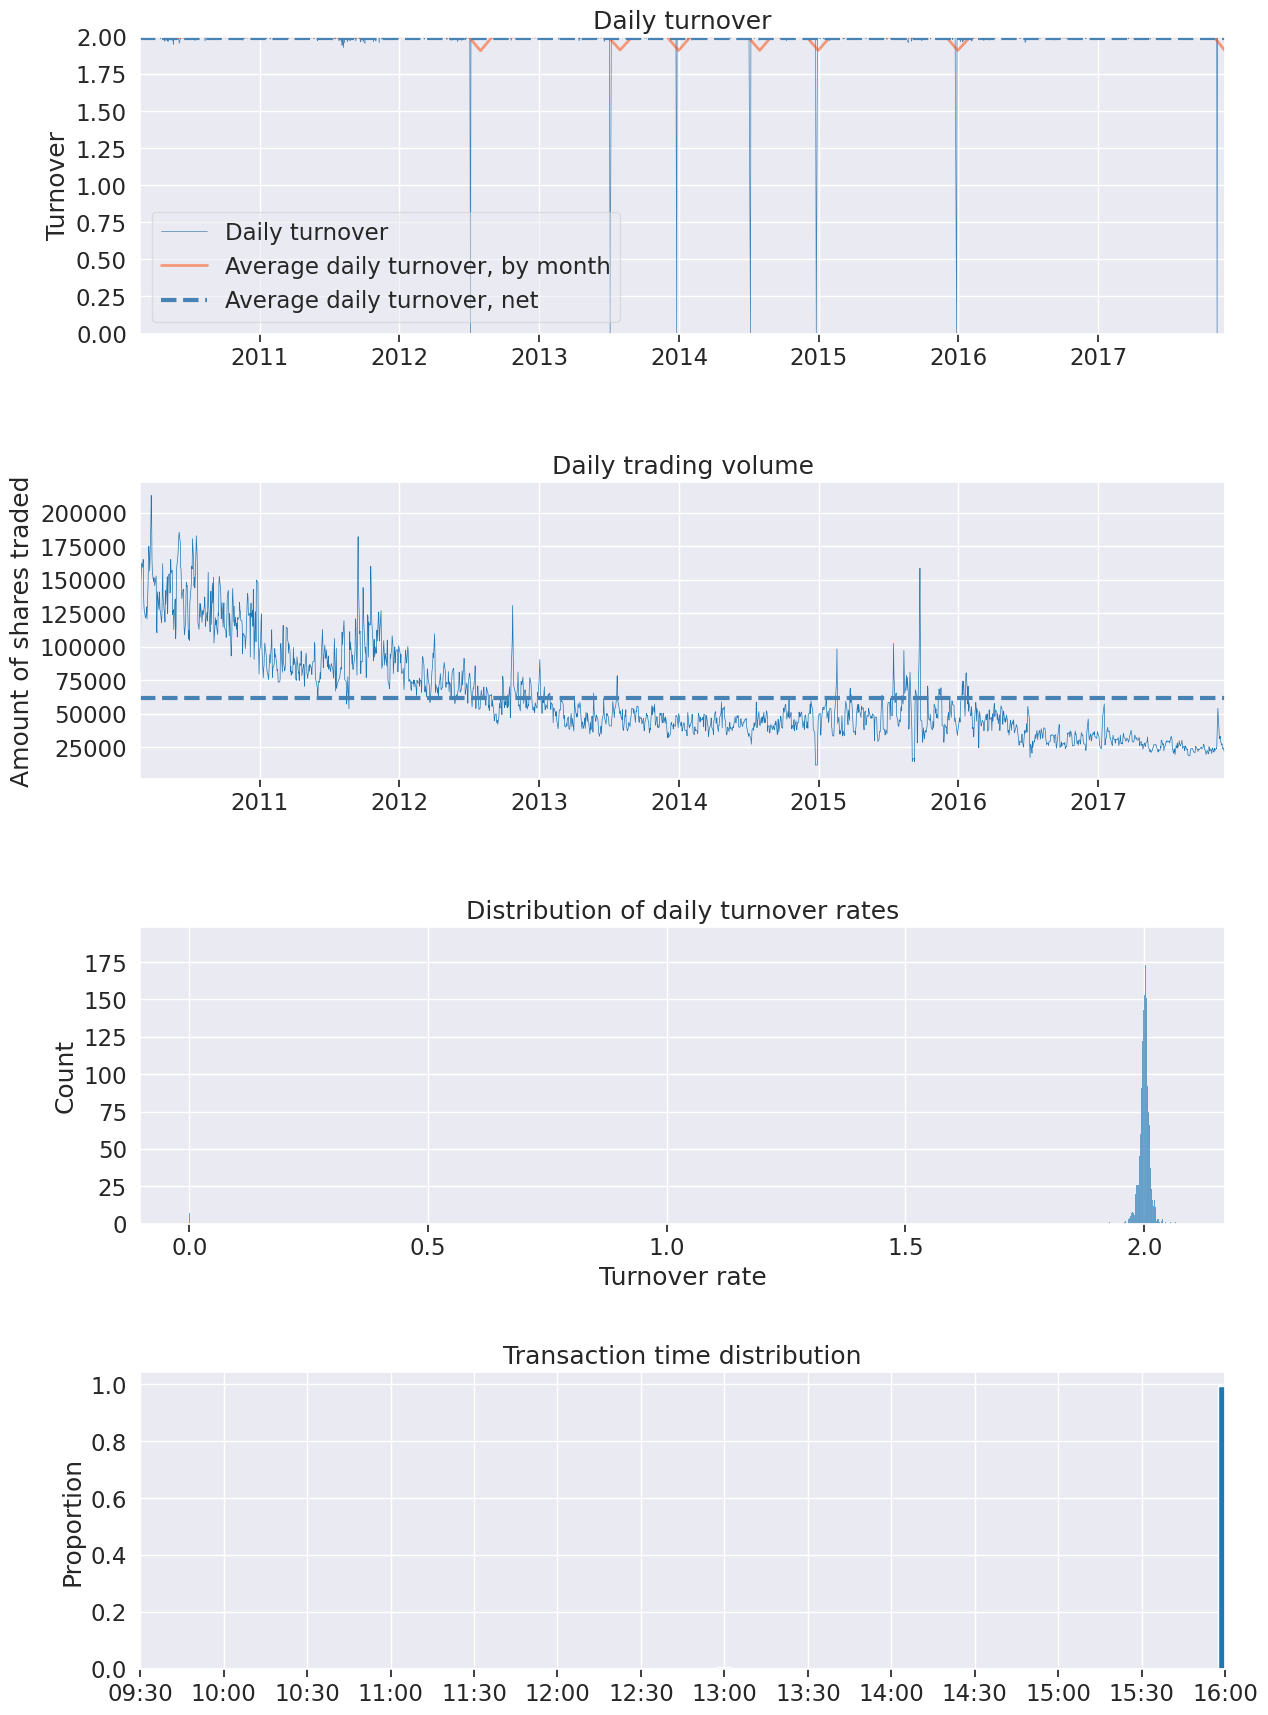

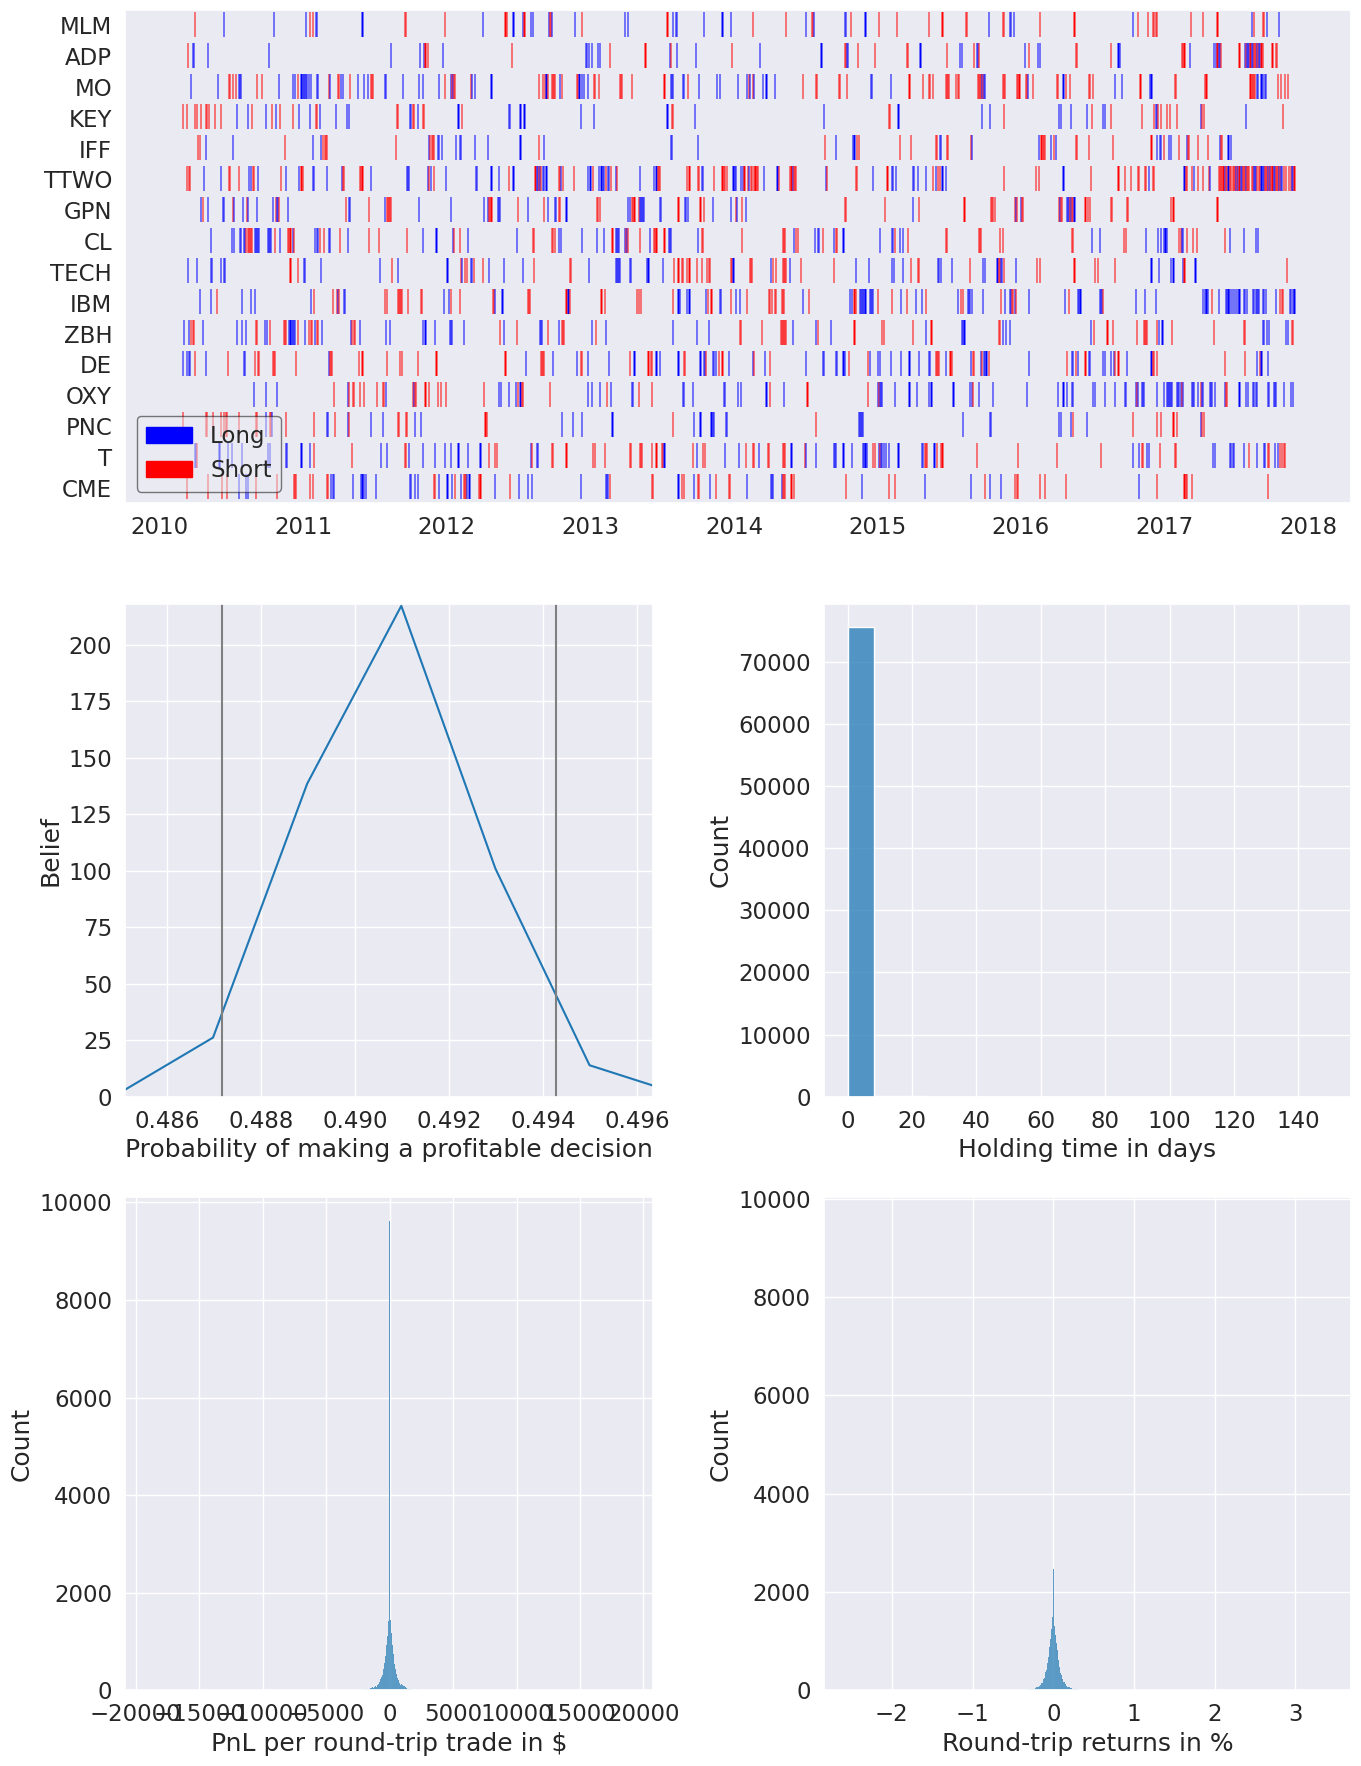

In [17]:
pf.create_full_tear_sheet(
    returns,
    transactions=transactions,
    positions=positions,
    live_start_date=LIVE_DATE,
    benchmark_rets=benchmark_data,
    round_trips=True
)

## Trading Strategy-II

### As seen in signal evaluations of the factors of the Ridge Model-17 (alpha=10000), we will long factors in quantile-2 and short factors in quantile-5

In [18]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":2,
        "quantile_short":5
    }
}

In [19]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=5,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.00,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge17_factor",
    trading_strategy=trading_strategy
)

In [20]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

#### Extracting Information from Zipline Results

In [21]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

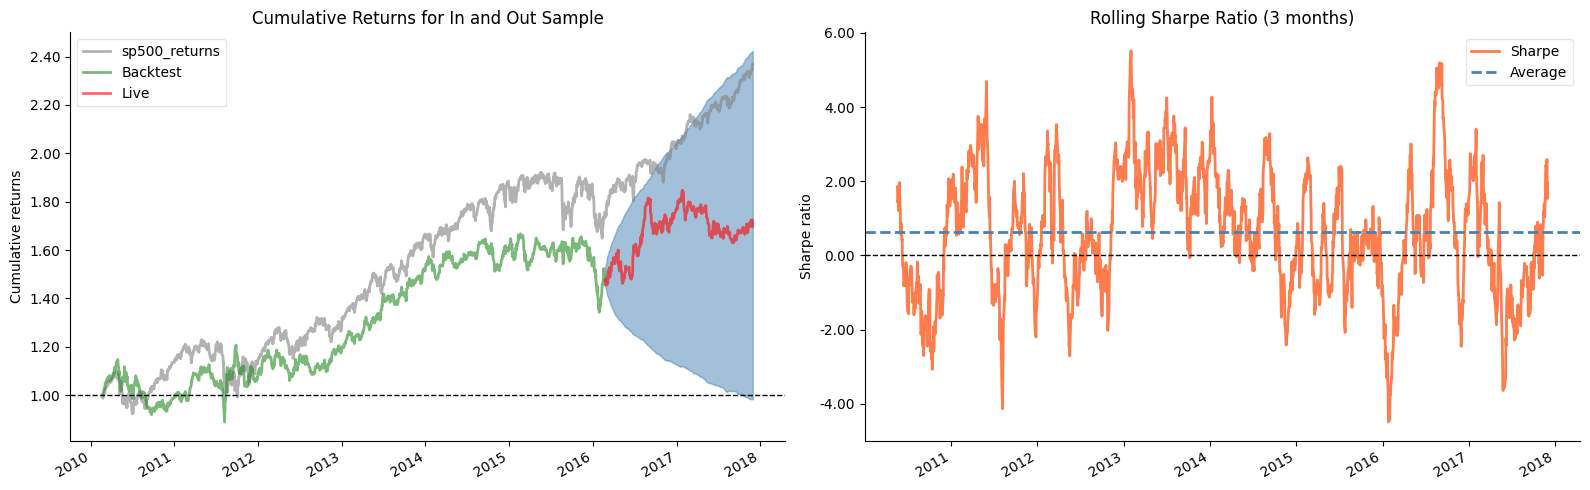

In [22]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,22.51,2010-04-29,2011-08-08,2011-09-21,365
1,19.46,2015-02-20,2016-01-29,2016-08-05,381
2,14.25,2011-09-27,2011-11-15,2013-01-11,339
3,11.73,2017-01-27,2017-09-07,NaT,NaN
4,8.26,2016-08-30,2016-10-06,2017-01-20,104


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.76%,-6.21%,7.66%
Fukushima,0.14%,-0.76%,1.81%
EZB IR Event,-0.02%,-1.14%,0.97%
Flash Crash,-0.74%,-2.61%,1.43%
Apr14,-0.05%,-1.53%,1.17%
Oct14,-0.22%,-1.89%,1.90%
Fall2015,-0.01%,-3.84%,3.12%
Recovery,0.03%,-6.21%,7.66%
New Normal,0.03%,-3.84%,4.08%


Top 10 long positions of all time,max
sid,
NEM,25.19%
OKE,24.54%
SMCI,24.02%
DECK,22.69%
WTW,21.20%
TXN,21.00%
ZBRA,20.98%
VRTX,20.53%
CF,20.05%


Top 10 short positions of all time,max
sid,
OKE,-29.43%
WTW,-27.01%
SMCI,-24.64%
VZ,-24.58%
FCX,-23.89%
C,-21.49%
SBUX,-20.94%
NRG,-20.60%
URI,-20.31%


Top 10 positions of all time,max
sid,
OKE,29.43%
WTW,27.01%
NEM,25.19%
SMCI,24.64%
VZ,24.58%
FCX,23.89%
DECK,22.69%
C,21.49%
TXN,21.00%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$771631.26,$-330725.91,$1102357.17
Gross profit,$22596526.79,$9135183.37,$13461343.42
Gross loss,$-21824895.52,$-9465909.28,$-12358986.25
Profit factor,$1.04,$0.97,$1.09
Avg. trade net profit,$13.86,$-14.86,$33.01
Avg. winning trade,$813.79,$853.36,$788.97
Avg. losing trade,$-796.88,$-830.42,$-772.97
Ratio Avg. Win:Avg. Loss,$1.02,$1.03,$1.02
Largest winning trade,$31450.58,$31450.58,$19810.98
Largest losing trade,$-42278.20,$-42278.20,$-38352.30


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 11:45:49.208103494,1 days 13:27:49.897488881,1 days 10:37:49.053991735
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,156 days 20:00:00,156 days 20:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 20:59:59


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,1.99%,1.99%,1.27%
Largest losing trade,-2.64%,-2.64%,-2.61%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,0.00%,0.00%,0.01%,0.00%,0.00%,0.00%,-0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.02%,0.01%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,-0.01%,-0.00%,-0.00%,0.02%,0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.00%,0.00%,0.01%,0.01%,0.01%,0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,0.01%,0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,0.02%,0.01%,-0.01%,-0.01%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,-0.00%,-0.01%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.01%,0.01%,0.02%,-0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.00%,-0.02%,0.00%,0.00%,0.01%,-0.02%,0.01%,0.01%,0.01%,0.00%,-0.01%,0.01%,0.01%,-0.00%,0.01%,0.01%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,-0.01%,0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,0.01%,0.01%,0.00%,0.01%,0.02%,0.00%,0.00%,0.01%,0.00%,0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.01%,-0.01%,0.01%,-0.00%,0.01%,0.00%,0.01%,0.01%,0.00%,-0.01%,0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.02%,0.00%,0.01%,-0.00%,-0.01%,0.02%,0.02%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.02%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.01%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.02%,0.03%,-0.00%,0.01%,0.02%,-0.00%,0.01%,-0.01%,0.01%,0.00%,0.01%,0.01%,0.01%,-0.01%,-0.00%,0.00%,-0.01%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.01%,0.00%,0.01%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,-0.01%,0.01%,0.00%,-0.01%,0.00%,-0.01%,-0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.01%,-0.00%,0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,-0.01%,0.00%,0.01%,0.00%,-0.00%,0.01%,0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.01%,-0.00%,0.00%,0.00%,0.01%,-0.01%,-0.00%,0.01%,-0.00%,-0.01%,0.01%,-0.00%,-0.02%,-0.00%,0.00%,0.00%,0.00%,0.01%,0.01%,0.01%,0.01%,0.00%,0.01%,0.01%,-0.01%,-0.01%,-0.00%,-0.02%,0.00%,0.01%,-0.00%,-0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.01%,0.01%,0.02%,0.00%,-0.00%,0.01%,0.00%,-0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.02%,-0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.02%,-0.01%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.01%,0.01%,0.01%,0.02%,-0.02%,0.00%,0.00%,-0.01%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.01%,0.02%,-0.00%,0.01%,-0.01%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,0.01%,0.00%,0.01%,0.01%
Avg returns winning,0.07%,0.03%,0.

Profitability (PnL / PnL total) per name,
symbol,
CF,10.05%
VLO,6.30%
TYL,6.29%
CRM,5.96%
HAL,5.31%
EQT,5.05%
WMB,4.98%
OXY,4.66%
DVN,4.64%


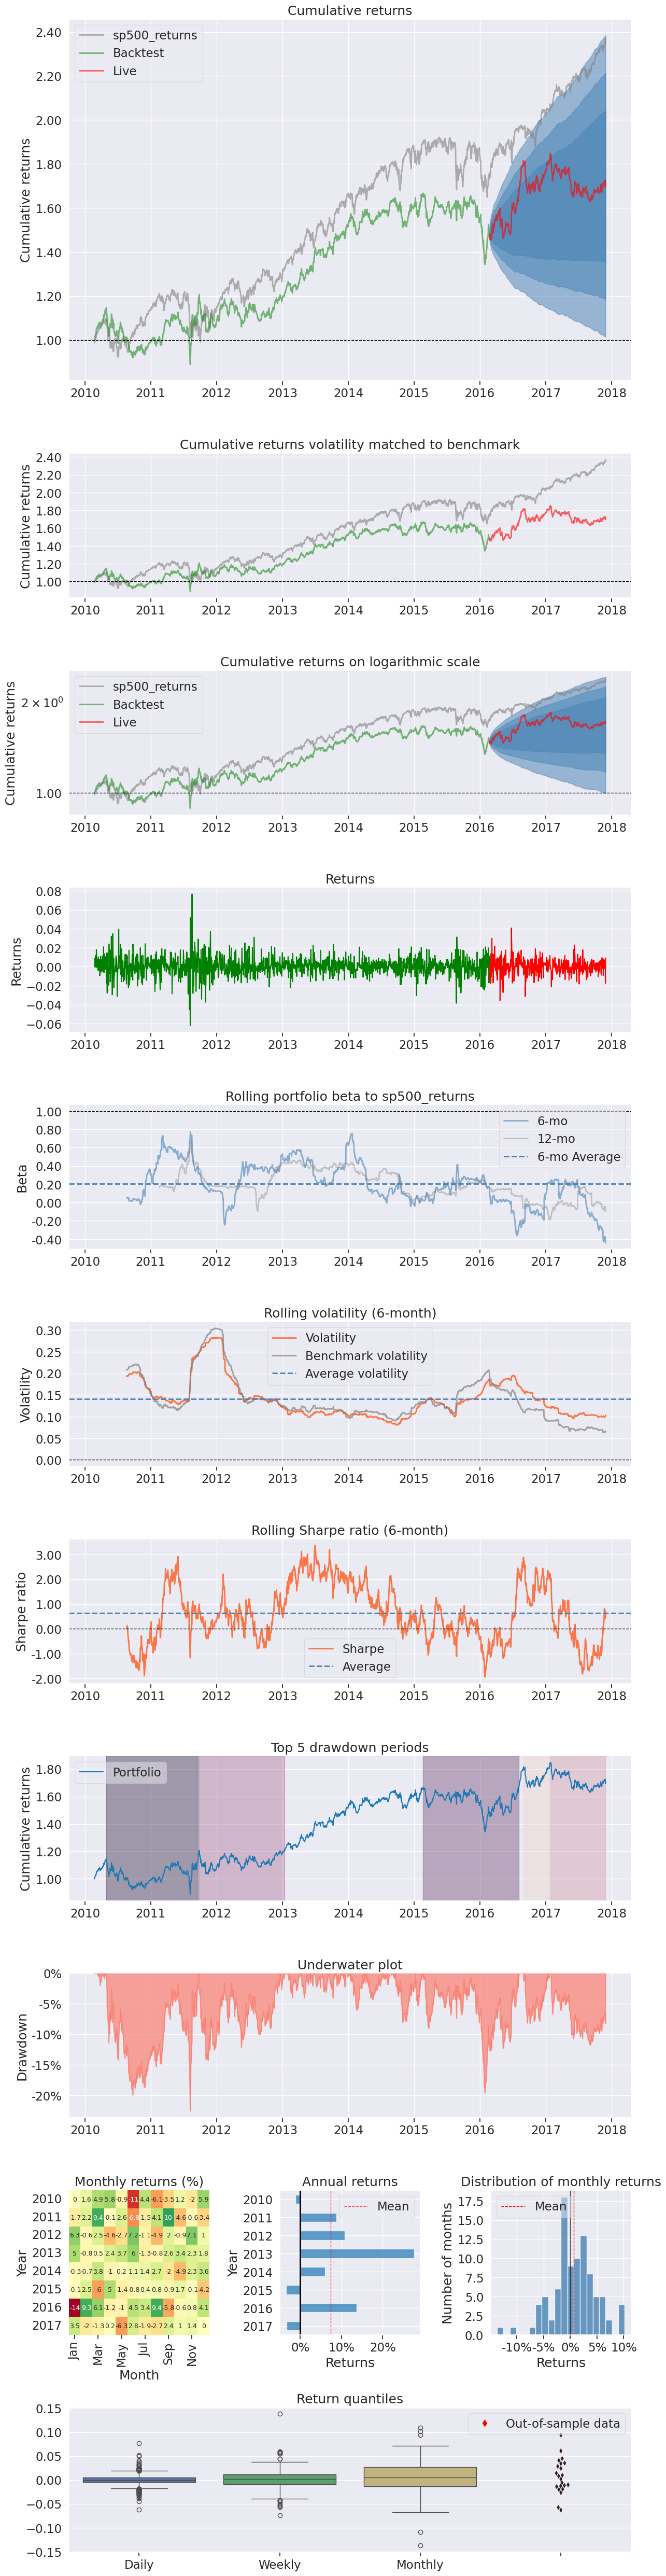

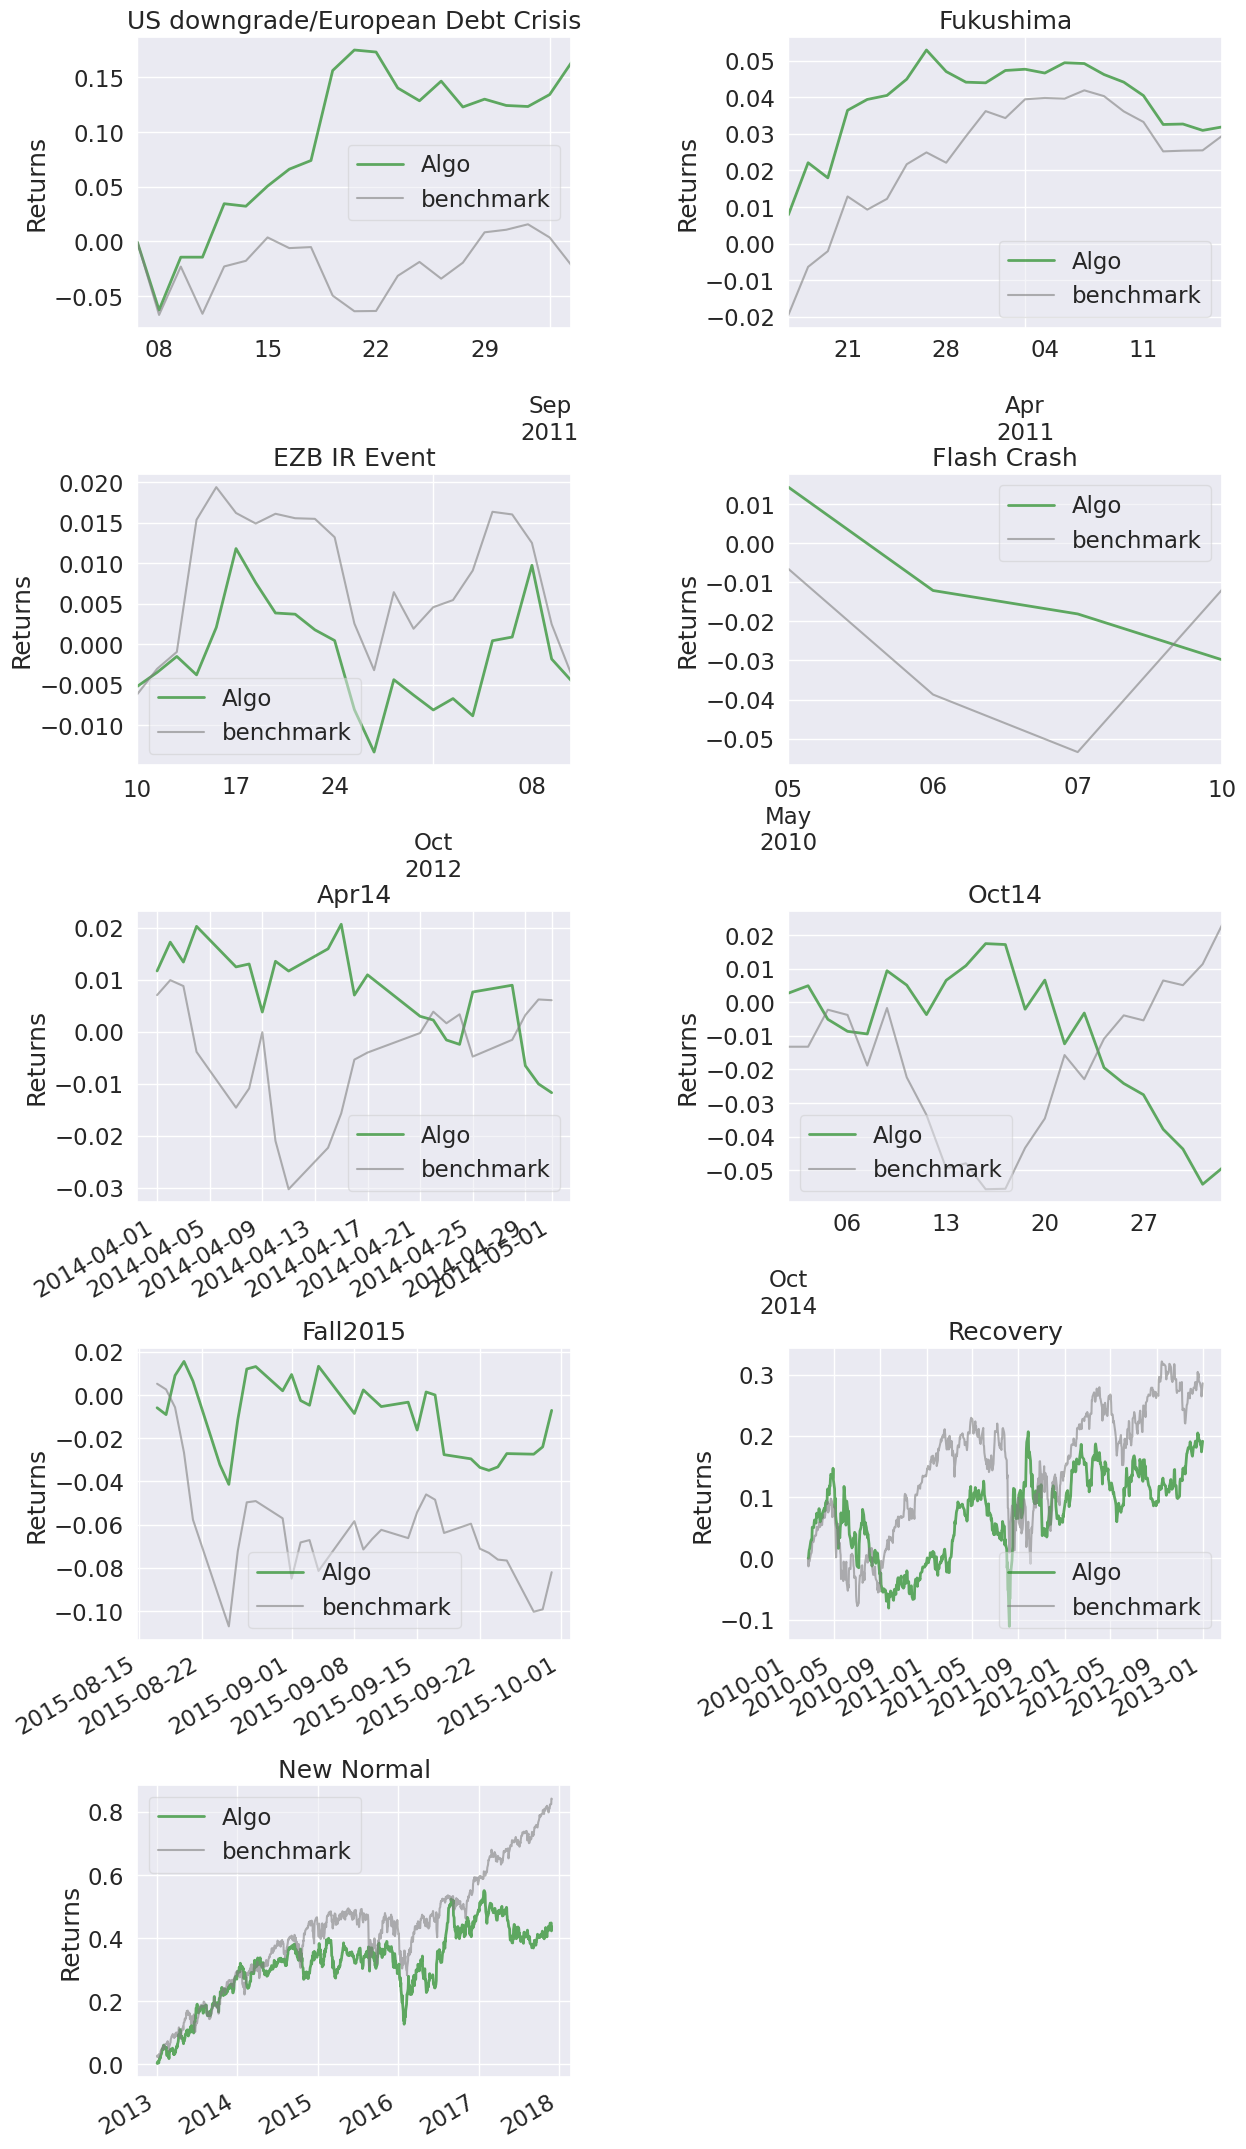

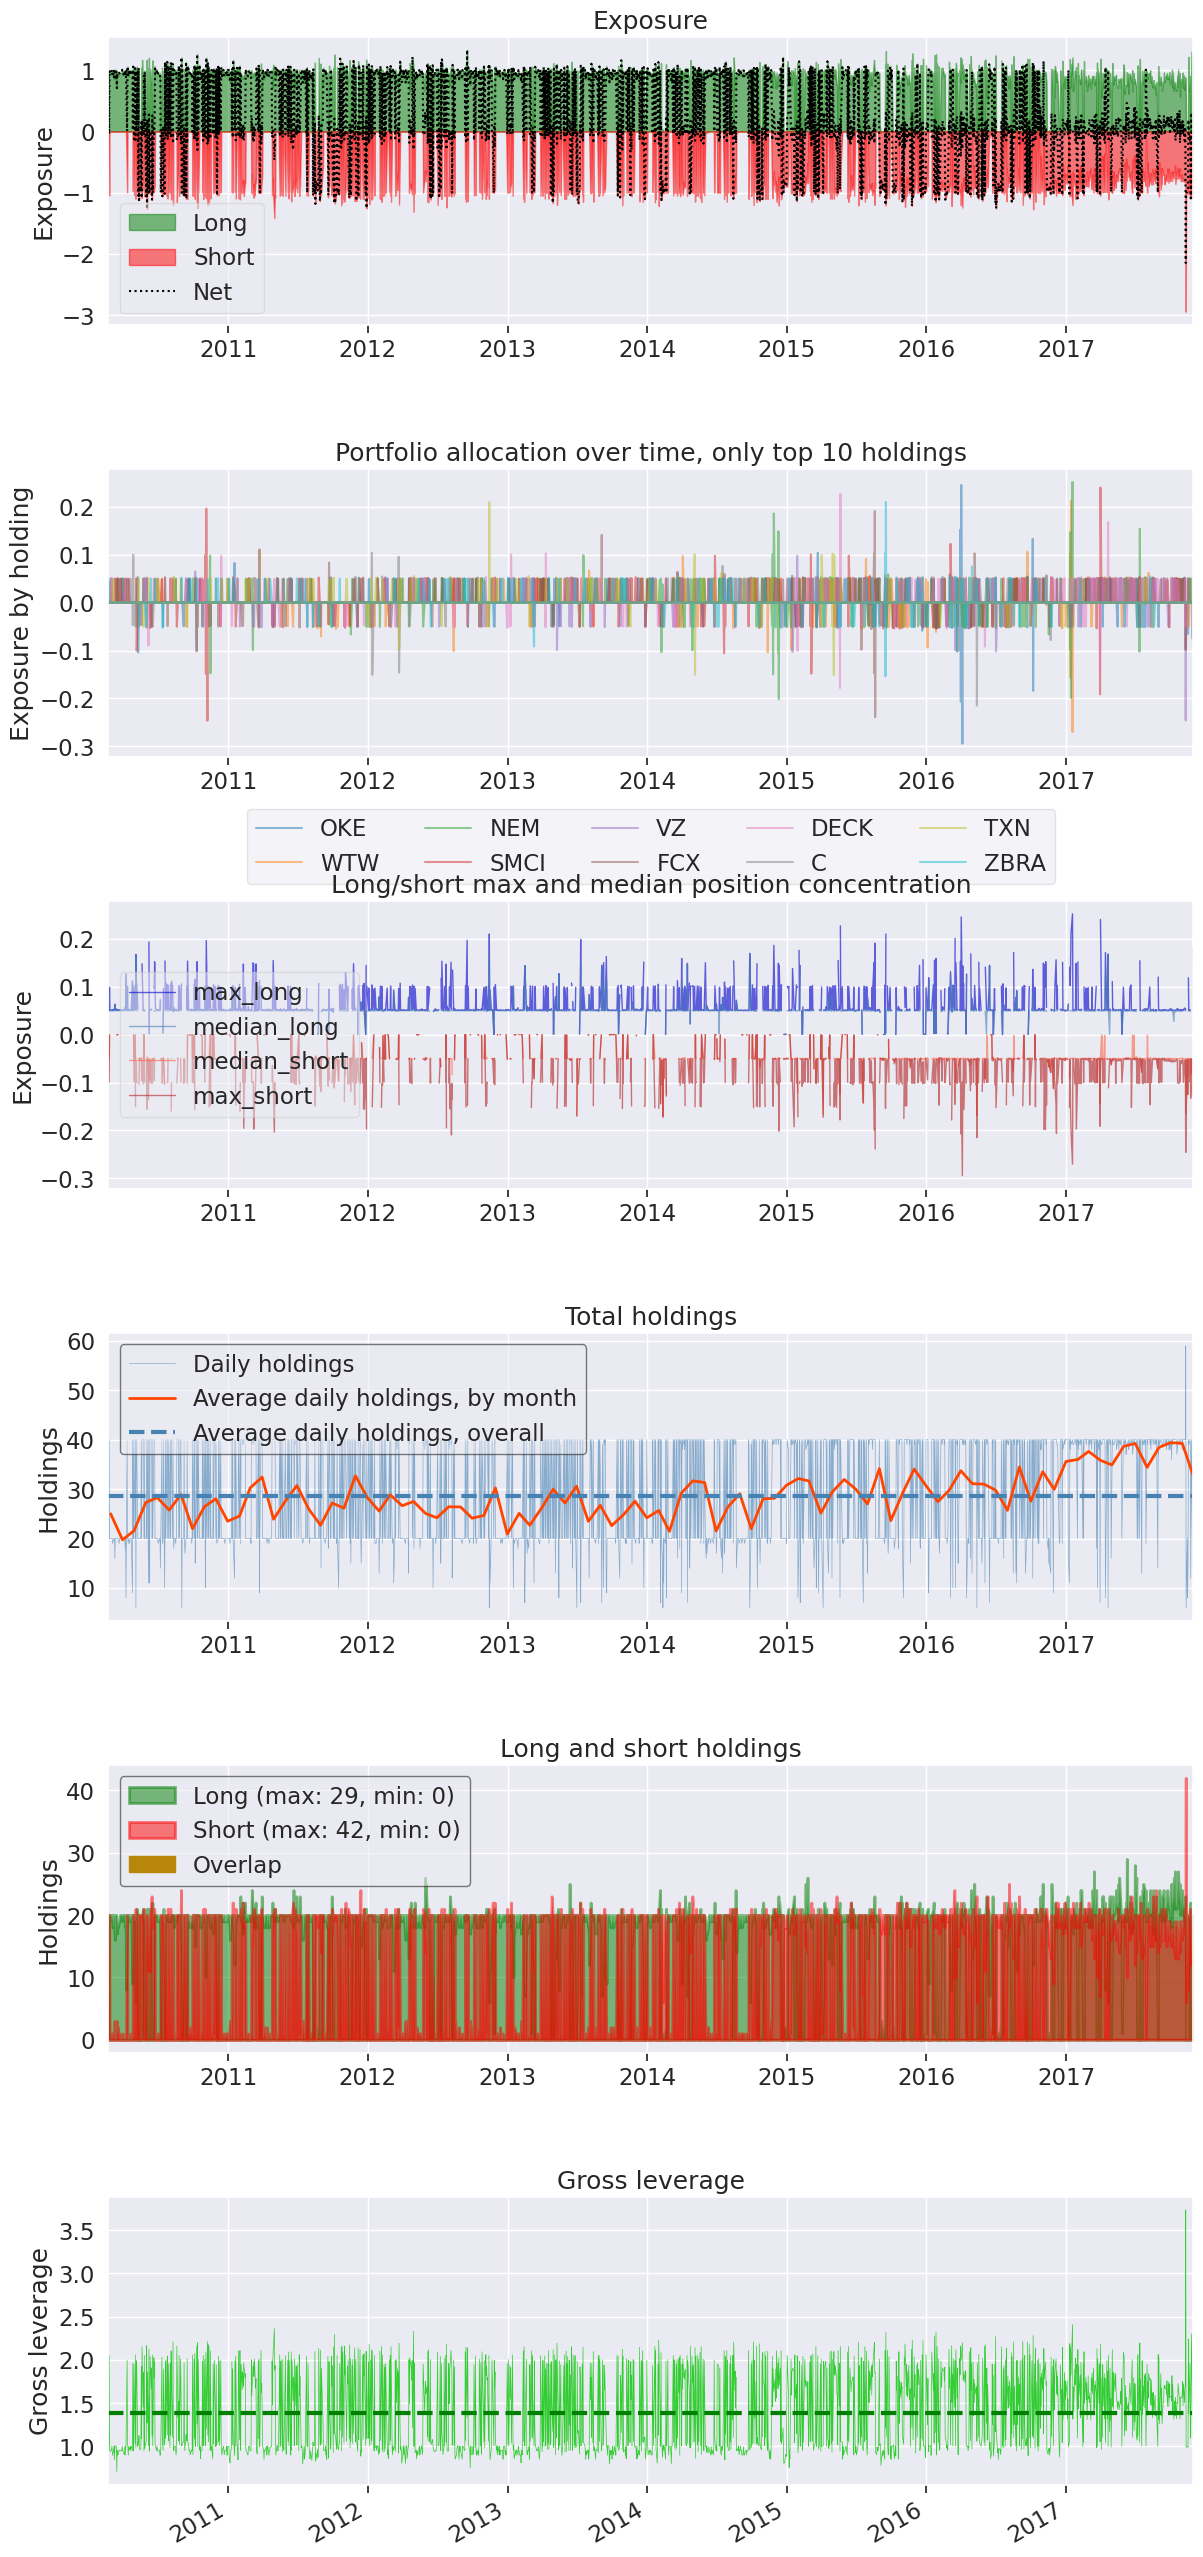

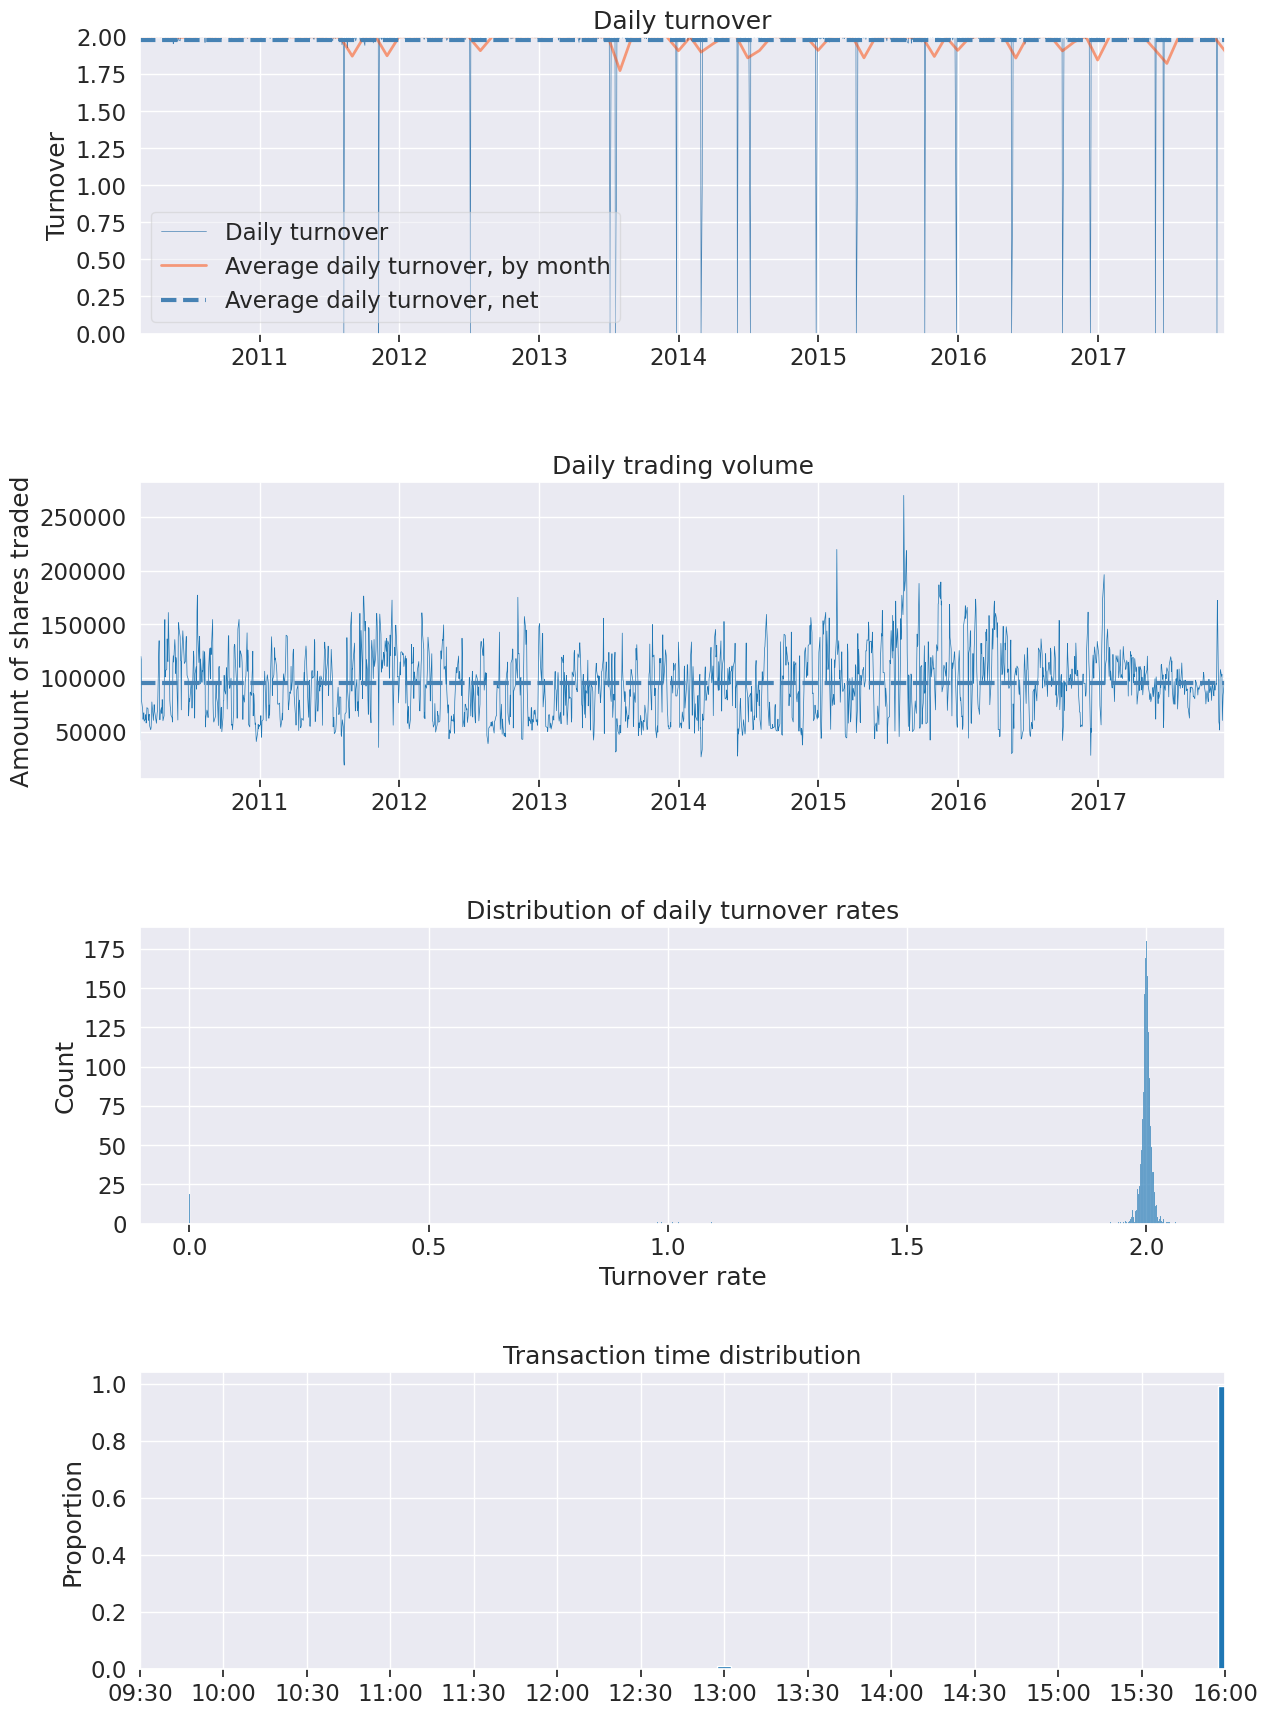

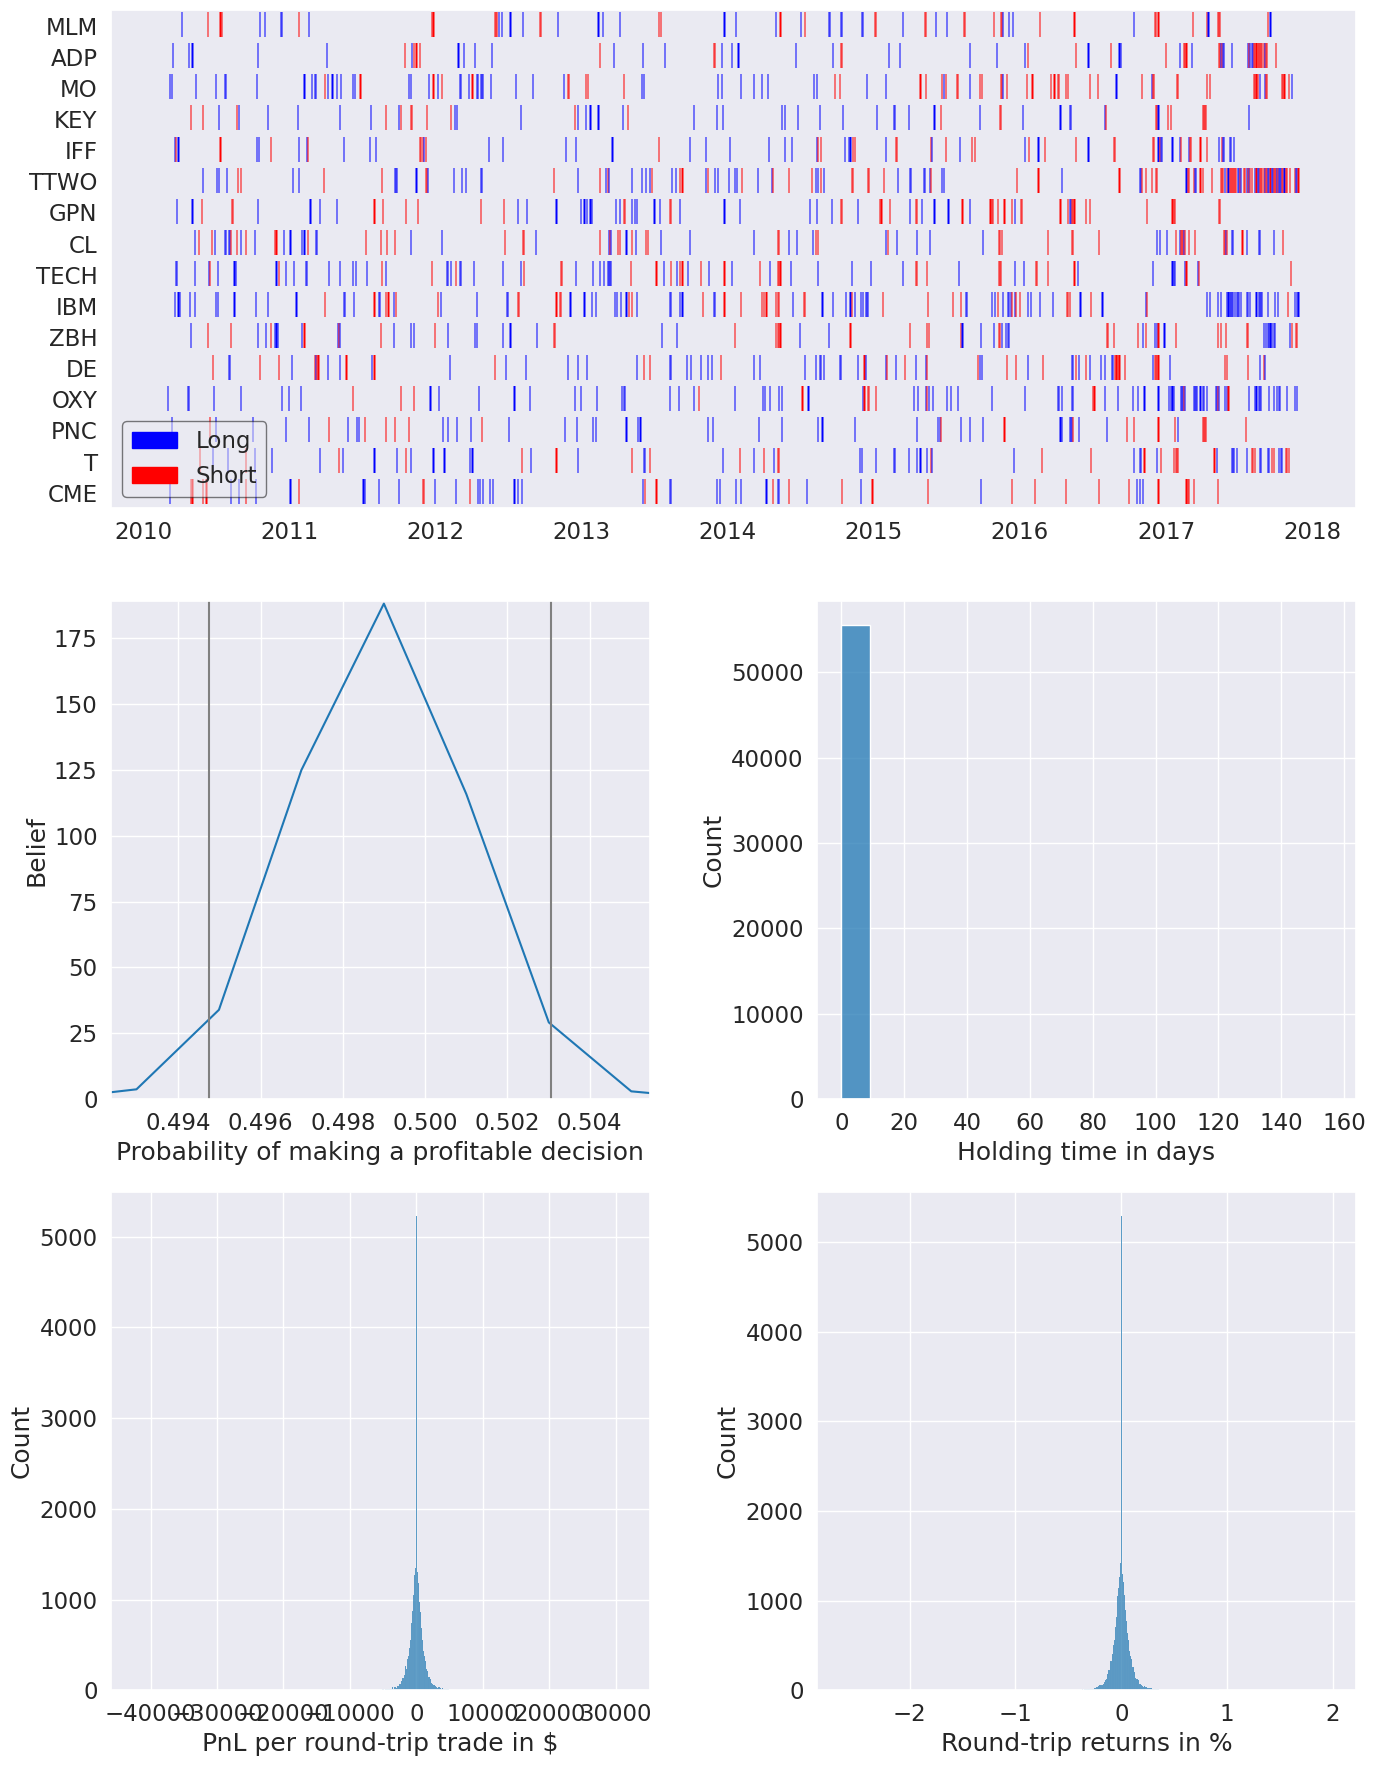

In [23]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)